<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">
<h1 style="color: white; font-size: 2.2em; margin: 0;">🛒 Amazon Products — Complete EDA & ML</h1>
<p style="color: #FFD700; font-size: 1.1em; margin-top: 10px;">Price Prediction · Category Analysis · Feature Engineering · Model Comparison</p>
</div>

---

## 🏆 What Makes This Notebook Stand Out
- ✅ **Complete EDA** — distributions, outliers, missing values, correlations
- ✅ **Feature Engineering** — text features, category encoding, price tiers
- ✅ **5 ML Models** compared — Linear, Ridge, Random Forest, XGBoost, GBM
- ✅ **Hyperparameter Tuning** — GridSearchCV on best model
- ✅ **Statistical Tests** — ANOVA, Kruskal-Wallis, Spearman correlation
- ✅ **Business Insights** — actionable findings for sellers and analysts
- ✅ **Beginner-Friendly** — every step explained with real-world analogies

---

## 📋 Table of Contents
| # | Section | Description |
|---|---|---|
| 1 | [Setup & Data Loading](#s1) | Libraries, load CSV, first look |
| 2 | [Data Cleaning](#s2) | Price parsing, missing values, duplicates |
| 3 | [Feature Engineering](#s3) | Text features, category flags, price tiers |
| 4 | [Univariate Analysis](#s4) | Distributions, outliers, normality tests |
| 5 | [Category Analysis](#s5) | Top categories, price by category |
| 6 | [Availability Analysis](#s6) | Stock status patterns |
| 7 | [Correlation & Bivariate](#s7) | Heatmap, scatter plots |
| 8 | [Statistical Hypothesis Testing](#s8) | ANOVA, Kruskal-Wallis, Spearman |
| 9 | [ML Problem Framing](#s9) | Feature matrix, train/test split |
| 10 | [Model Selection Framework](#s10) | Model comparison table, metrics |
| 11 | [Regression Models](#s11) | 5 models trained and evaluated |
| 12 | [Hyperparameter Tuning](#s12) | GridSearchCV on best model |
| 13 | [Model Comparison](#s13) | Side-by-side results, feature importance |
| 14 | [Key Insights & Report](#s14) | Business findings, recommendations |

---

> 💡 **If this notebook helped you, please upvote! It motivates me to create more quality content.** ⬆️


## 1. Setup & Data Loading 🔧 <a id='s1'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px00; color: #0066cc;">
<b>Dataset:</b> Amazon India product listings — 1,436 products across Books, Kindle, Sports & more<br>
<b>Target:</b> Predict product price (INR) from category, name length, and availability<br>
<b>Source:</b> Web-scraped Amazon.in product pages
</div>


In [1]:
# ============================================================
# SECTION 1 — Setup & Data Loading
# ============================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import shapiro, kruskal, spearmanr, mannwhitneyu, f_oneway

# ML
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(f'✅ Pandas  : {pd.__version__}')
print(f'✅ NumPy   : {np.__version__}')
print(f'✅ XGBoost : {XGB_AVAILABLE}')
print('✅ All libraries loaded!')


✅ Pandas  : 2.3.3
✅ NumPy   : 2.0.2
✅ XGBoost : True
✅ All libraries loaded!


In [2]:
# Load dataset
df_raw = pd.read_csv('/kaggle/input/datasets/abbas829/e-commerce-product-and-web-scraped-datasets/amazon_products_data.csv', encoding='latin-1')
print(f'📦 Shape   : {df_raw.shape}')
print(f'📋 Columns : {df_raw.columns.tolist()}')
df_raw.head(3)


📦 Shape   : (1436, 17)
📋 Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \n Fedor G. Pikus (Au...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \nErnest Lynn \n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \nNinety Nine Cents Pres...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


In [3]:
# Column dictionary
col_info = {
    'rl'              : 'Product URL on Amazon.in',
    'asin'            : 'Amazon Standard Identification Number (unique ID)',
    'name'            : 'Product title/name',
    'overview'        : 'Short overview (mostly empty [])',
    'price'           : 'Price as string (e.g. "1,600.00")',
    'currency'        : 'Currency code (all INR)',
    'availability'    : 'Stock status text',
    'brand'           : 'Brand/author name',
    'about_item'      : 'Bullet-point features (mostly missing)',
    'img_source'      : 'Image URLs',
    'description'     : 'Full product description (mostly missing)',
    'specifications'  : 'Technical specs',
    'primary_category': 'Top-level category (Books, Kindle, Sports...)',
    'category_1'      : 'Sub-category level 1',
    'category_2'      : 'Sub-category level 2',
    'category_3'      : 'Sub-category level 3',
    'breadcrumbs'     : 'Full category path',
}
print('📖 Column Dictionary:')
for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100
    print(f'  {col:20s} | {desc[:45]:45s} | Missing: {missing_pct:.0f}%')


📖 Column Dictionary:
  rl                   | Product URL on Amazon.in                      | Missing: 0%
  asin                 | Amazon Standard Identification Number (unique | Missing: 0%
  name                 | Product title/name                            | Missing: 0%
  overview             | Short overview (mostly empty [])              | Missing: 0%
  price                | Price as string (e.g. "1,600.00")             | Missing: 24%
  currency             | Currency code (all INR)                       | Missing: 24%
  availability         | Stock status text                             | Missing: 33%
  brand                | Brand/author name                             | Missing: 1%
  about_item           | Bullet-point features (mostly missing)        | Missing: 92%
  img_source           | Image URLs                                    | Missing: 0%
  description          | Full product description (mostly missing)     | Missing: 92%
  specifications       | Technical spec

## 2. Data Cleaning 🧹 <a id='s2'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Key cleaning steps:</b><br>
• Parse price strings like "1,600.00" → float 1600.0<br>
• Handle missing values (price: 24%, availability: 33%, description: 92%)<br>
• Standardise availability text into clean categories<br>
• Remove duplicates
</div>


In [4]:
# ============================================================
# SECTION 2 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)


✅ Price parsed: 1,092 / 1,436 products
✅ Duplicate ASINs: 0
✅ Availability categories: {'In Stock': 607, 'Unknown': 477, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 80, 'Other': 20, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


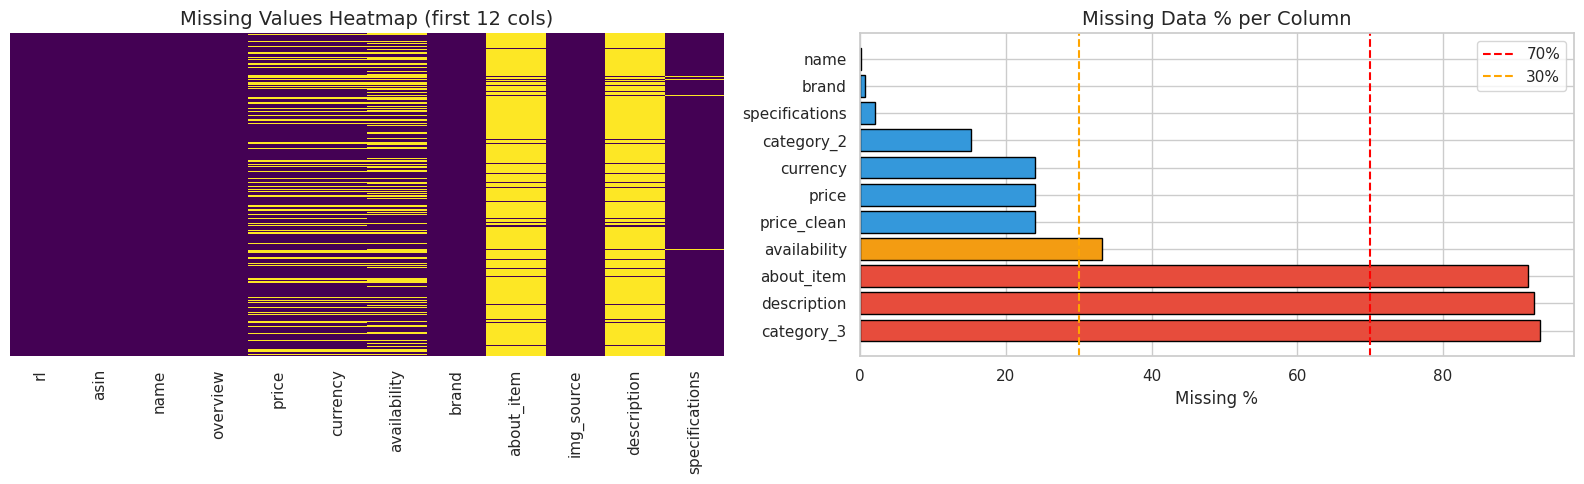

                Missing Count  Missing Pct
category_3               1340         93.3
description              1328         92.5
about_item               1317         91.7
availability              477         33.2
price_clean               344         24.0
price                     344         24.0
currency                  344         24.0
category_2                218         15.2
specifications             29          2.0
brand                      10          0.7
name                        1          0.1


In [5]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct'  : (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df[df.columns[:12]].isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]
axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')
axes[1].set_xlabel('Missing %'); axes[1].set_title('Missing Data % per Column')
axes[1].legend()

plt.tight_layout(); plt.show()
print(missing[missing['Missing Count'] > 0].to_string())


## 3. Feature Engineering 🛠️ <a id='s3'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Everyday Example:</b> A real estate agent doesn't just use raw square footage — they also consider location, age, and condition. We do the same: extract richer signals from raw text and categories.
</div>


In [6]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total features engineered: {len(df.columns)}')
print('\nPrice tier distribution:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)


✅ Total features engineered: 39

Price tier distribution:
price_tier
1_budget     104
2_low        285
3_mid        319
4_premium    258
5_luxury     126
Unknown      344


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 4. Univariate Analysis 📊 <a id='s4'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Key question:</b> What does the price distribution look like? Are there outliers? Is the data skewed?
</div>


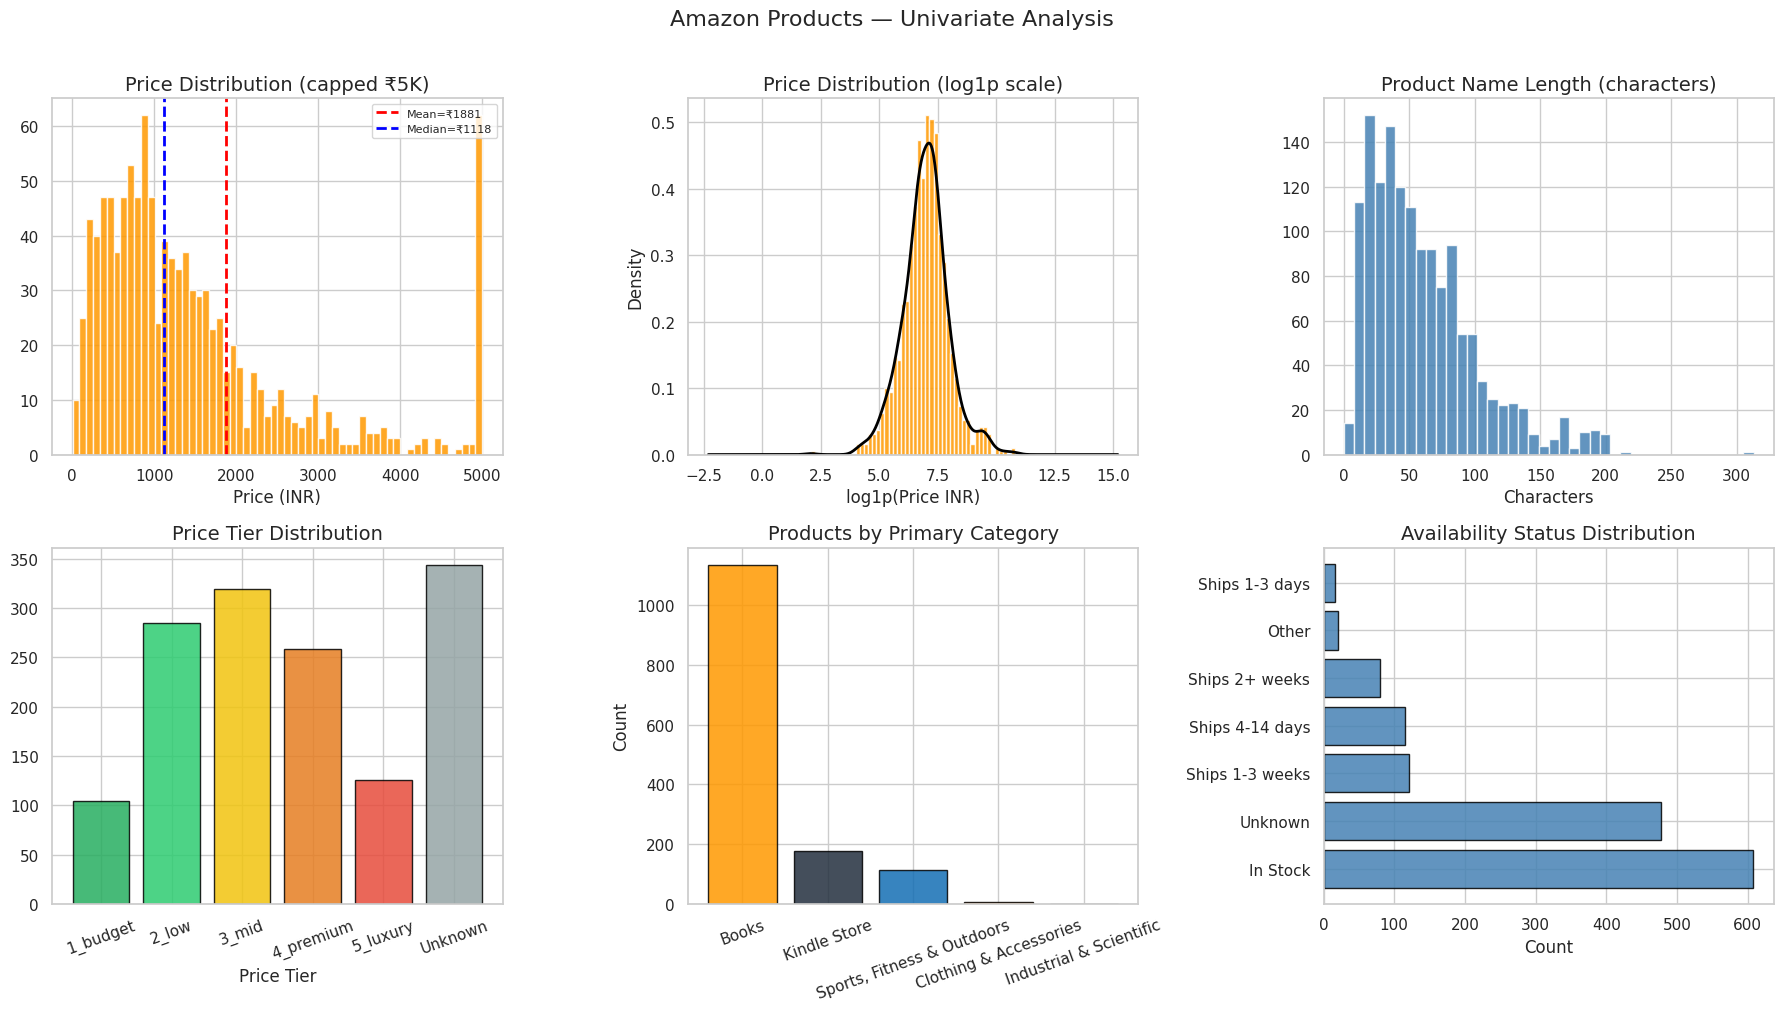

Shapiro-Wilk (log price, n=500): stat=0.9868, p=0.000175
Price is still non-normal after log transform

Price stats (INR):
count     1085.00
mean      1880.74
std       3342.61
min          7.00
25%        612.00
50%       1118.00
75%       1850.00
max      50555.00


In [7]:
# ============================================================
# SECTION 4 — Univariate Analysis
# ============================================================
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Price raw
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Mean=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Median=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Price Distribution (capped ₹5K)')
axes[0,0].set_xlabel('Price (INR)'); axes[0,0].legend(fontsize=8)

# Price log
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Price Distribution (log1p scale)')
axes[0,1].set_xlabel('log1p(Price INR)')

# Name length
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Product Name Length (characters)')
axes[0,2].set_xlabel('Characters')

# Price tier
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Price Tier Distribution')
axes[1,0].set_xlabel('Price Tier'); axes[1,0].tick_params(axis='x', rotation=20)

# Primary category
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Products by Primary Category')
axes[1,1].set_ylabel('Count'); axes[1,1].tick_params(axis='x', rotation=20)

# Availability
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Availability Status Distribution')
axes[1,2].set_xlabel('Count')

plt.suptitle('Amazon Products — Univariate Analysis', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

# Normality test
stat, p = shapiro(df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42))
print(f'Shapiro-Wilk (log price, n=500): stat={stat:.4f}, p={p:.6f}')
print(f'Price is {"normally distributed after log transform" if p > 0.05 else "still non-normal after log transform"}')
print(f'\nPrice stats (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())


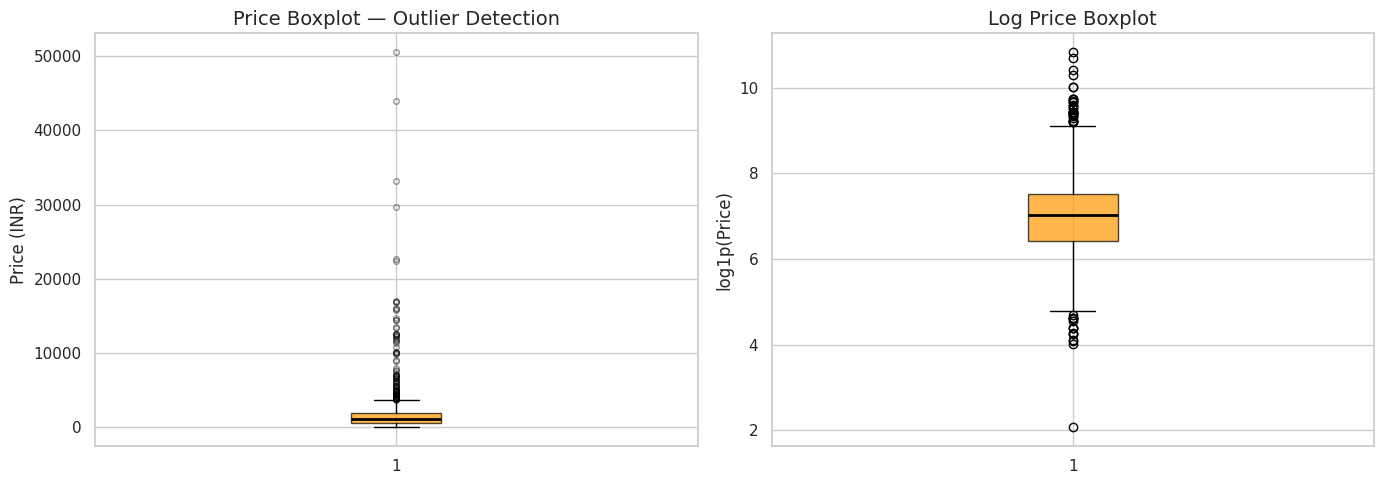

IQR method outliers: 93 (8.6%)
Price range (non-outlier): ₹-1245 – ₹3707

Top 10 most expensive products:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     29633.00                 

In [8]:
# Outlier analysis — boxplot and IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Price Boxplot — Outlier Detection')
axes[0].set_ylabel('Price (INR)')

axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Log Price Boxplot')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]
print(f'IQR method outliers: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Price range (non-outlier): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')
print(f'\nTop 10 most expensive products:')
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))


## 5. Category Analysis 🗂️ <a id='s5'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Key question:</b> Which categories have the highest prices? Which sub-categories dominate? Where is the most value?
</div>


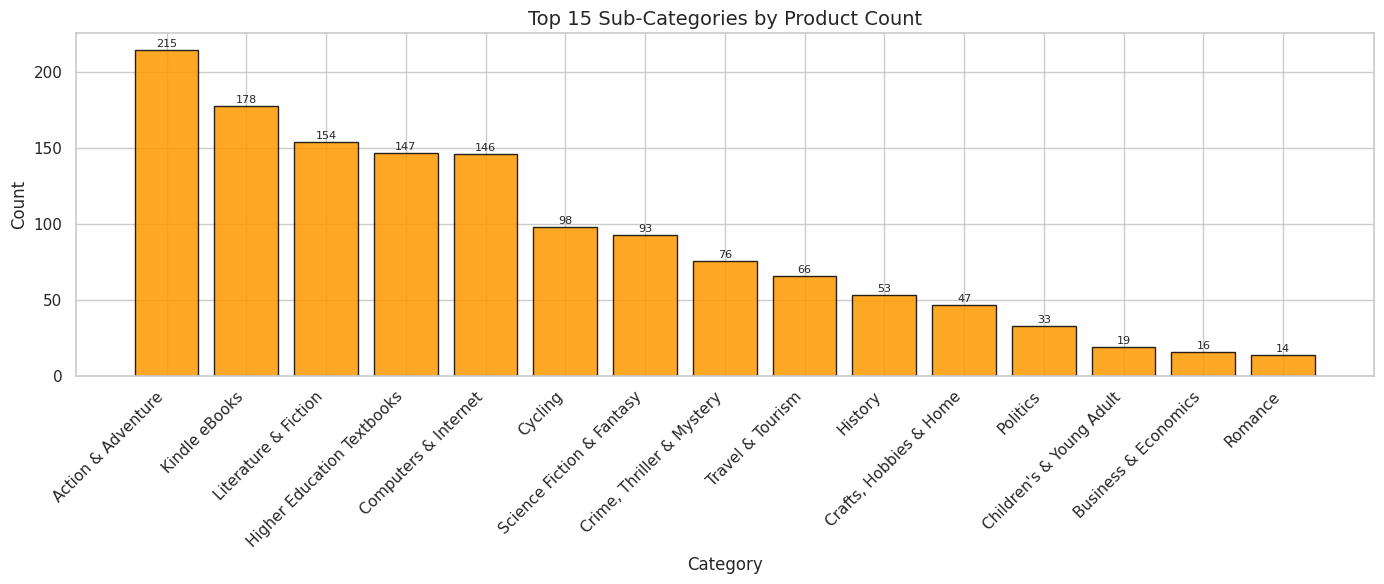

In [9]:
# ============================================================
# SECTION 5 — Category Analysis
# ============================================================
# Top 15 sub-categories by count
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)
plt.title('Top 15 Sub-Categories by Product Count')
plt.xlabel('Category'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


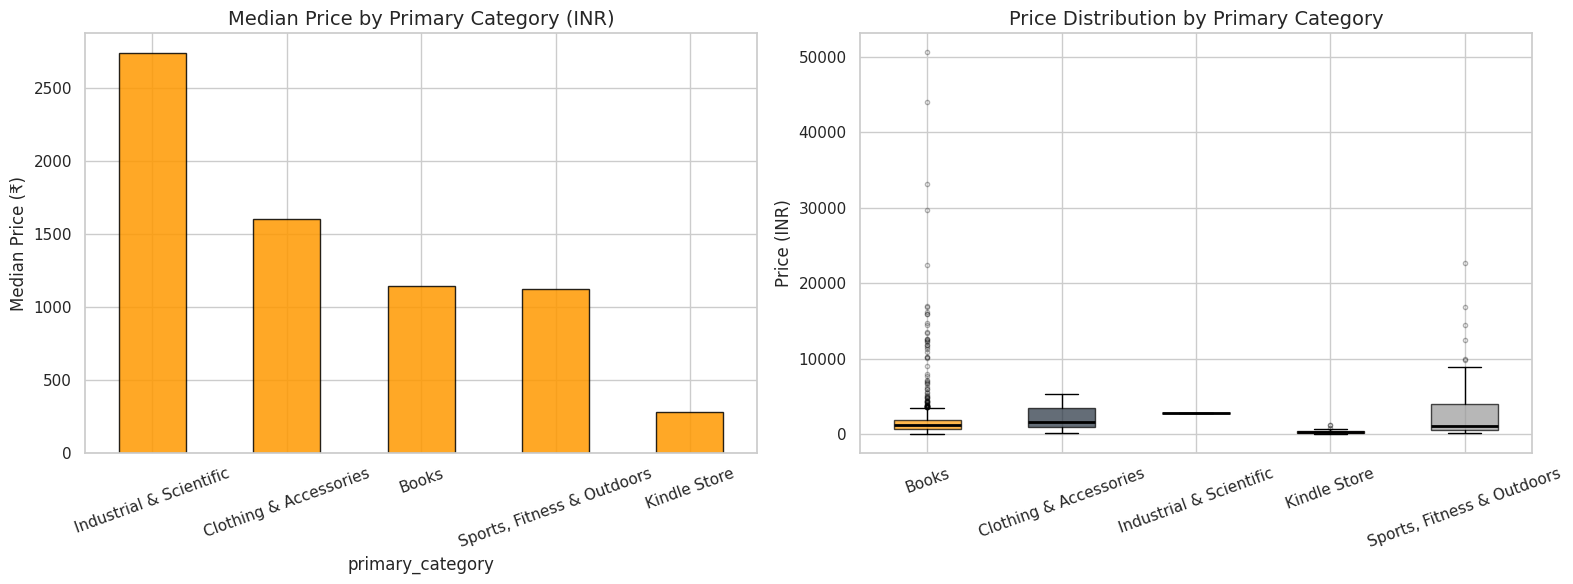

Price stats by primary category:
                              mean  median  count
primary_category                                 
Books                       1825.6  1145.0    955
Clothing & Accessories      2249.2  1606.5      6
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93


In [10]:
# Price by primary category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Primary Category (INR)')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=20)

# Boxplot
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]
bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Price Distribution by Primary Category')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()
print('Price stats by primary category:')
print(cat_price.to_string())


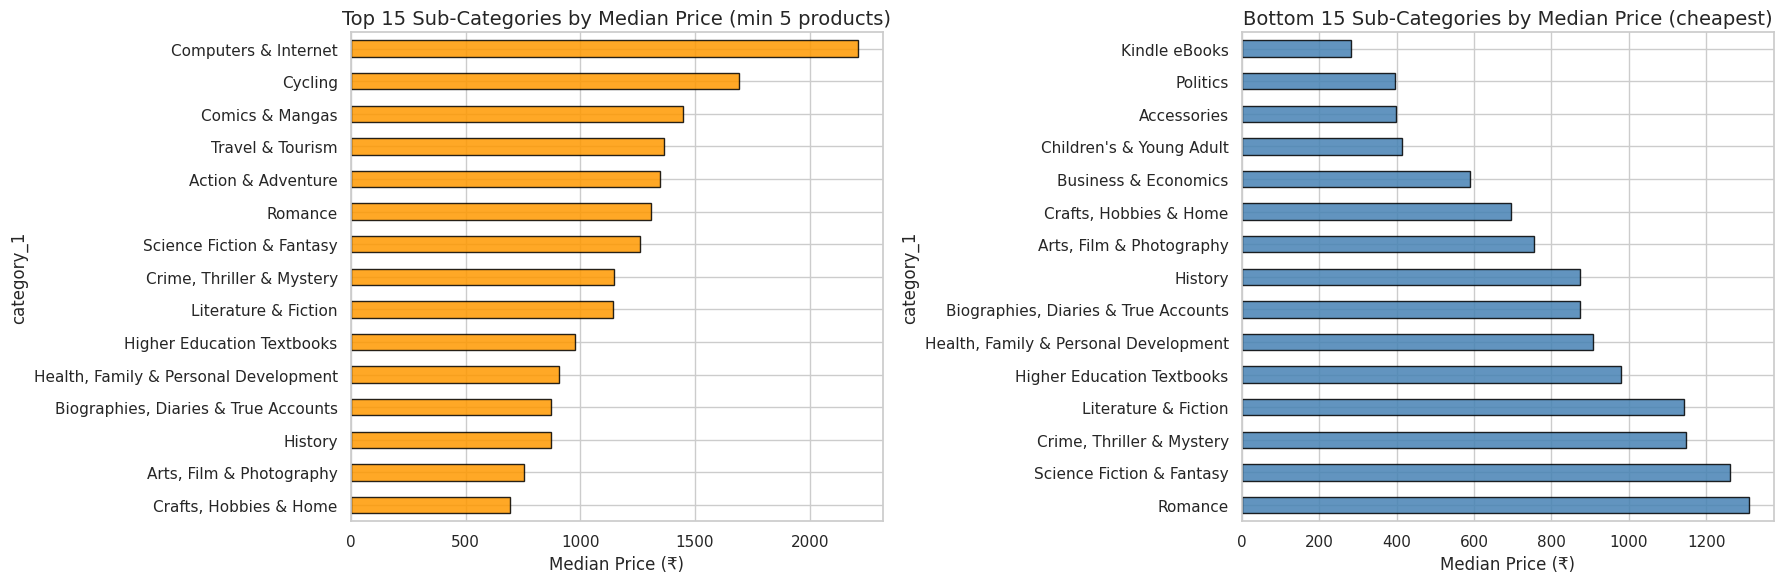

In [11]:
# Top 15 sub-categories by median price
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 Sub-Categories by Median Price (min 5 products)')
axes[0].set_xlabel('Median Price (₹)')

# Bottom 15 (cheapest)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Bottom 15 Sub-Categories by Median Price (cheapest)')
axes[1].set_xlabel('Median Price (₹)')

plt.tight_layout(); plt.show()


## 6. Availability Analysis 📦 <a id='s6'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Key question:</b> Does availability status affect price? Are premium products more likely to be out of stock?
</div>


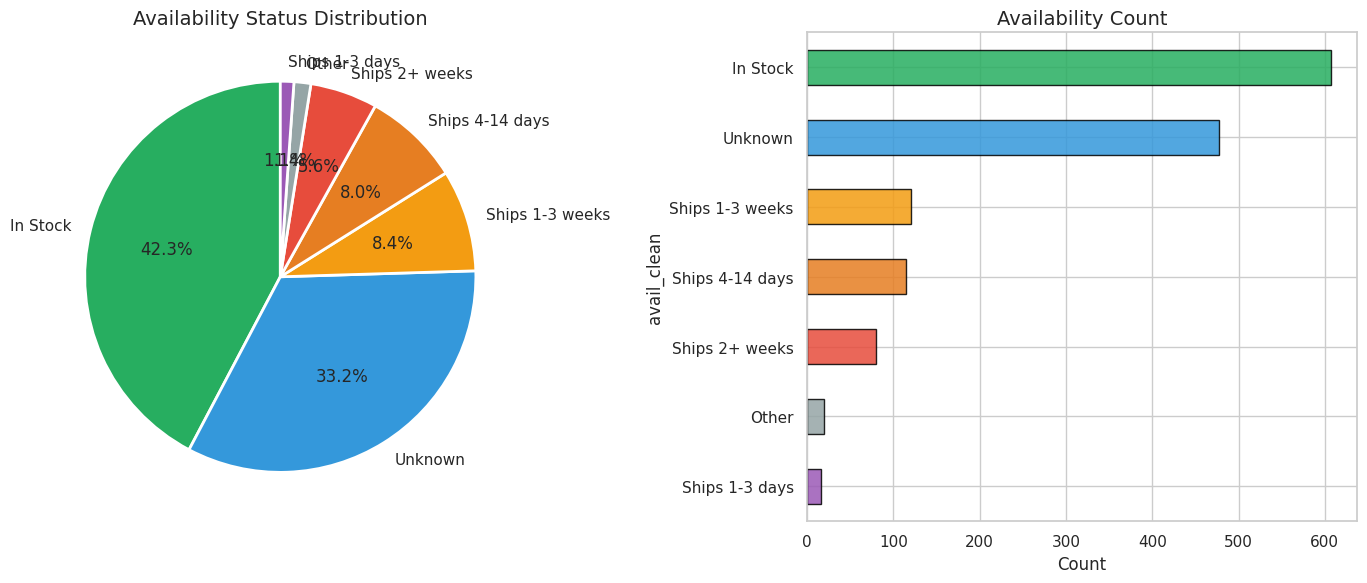

In [12]:
# ============================================================
# SECTION 6 — Availability Analysis
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Availability Status Distribution')

avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Availability Count')
axes[1].set_xlabel('Count')

plt.tight_layout(); plt.show()


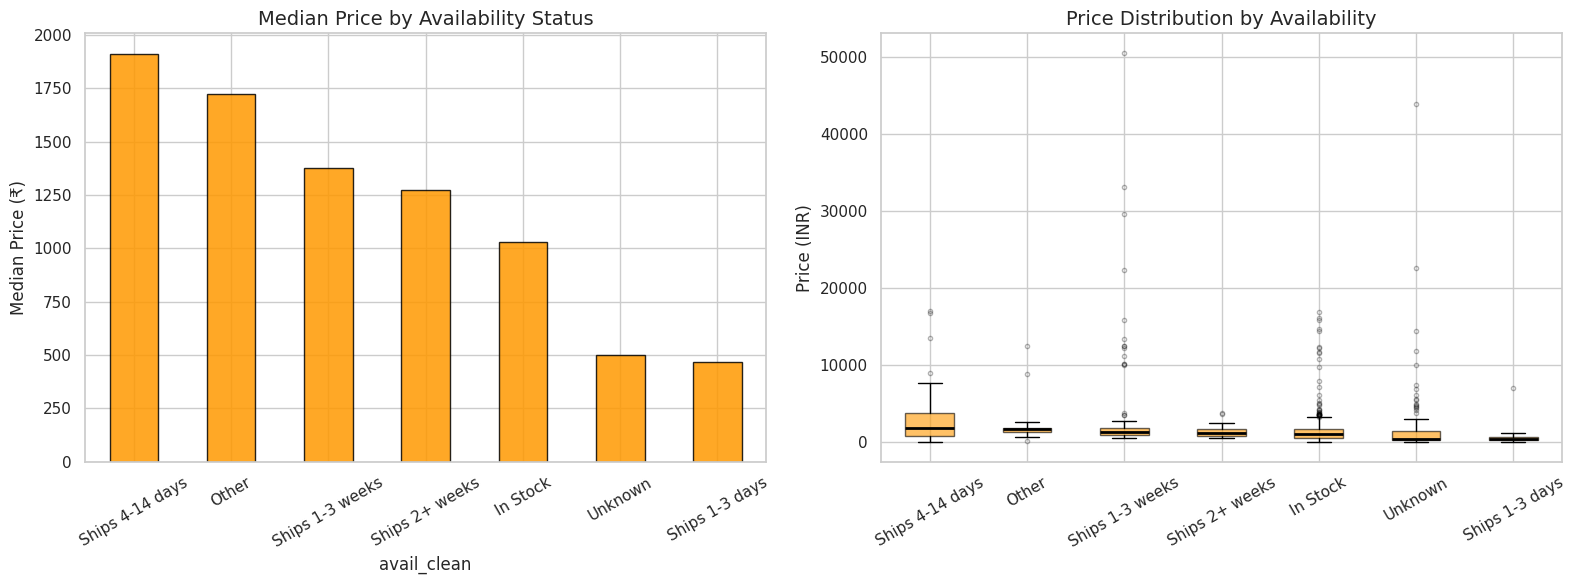

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1724.2  2459.4     20
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1030.0  1490.5    599
Unknown           502.0  1881.5    134
Ships 1-3 days    469.0   874.9     16


In [13]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print('Price by availability:')
print(avail_price.to_string())


## 7. Correlation & Bivariate Analysis 🔗 <a id='s7'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Key question:</b> Which features are most correlated with price? Does name length predict price?
</div>


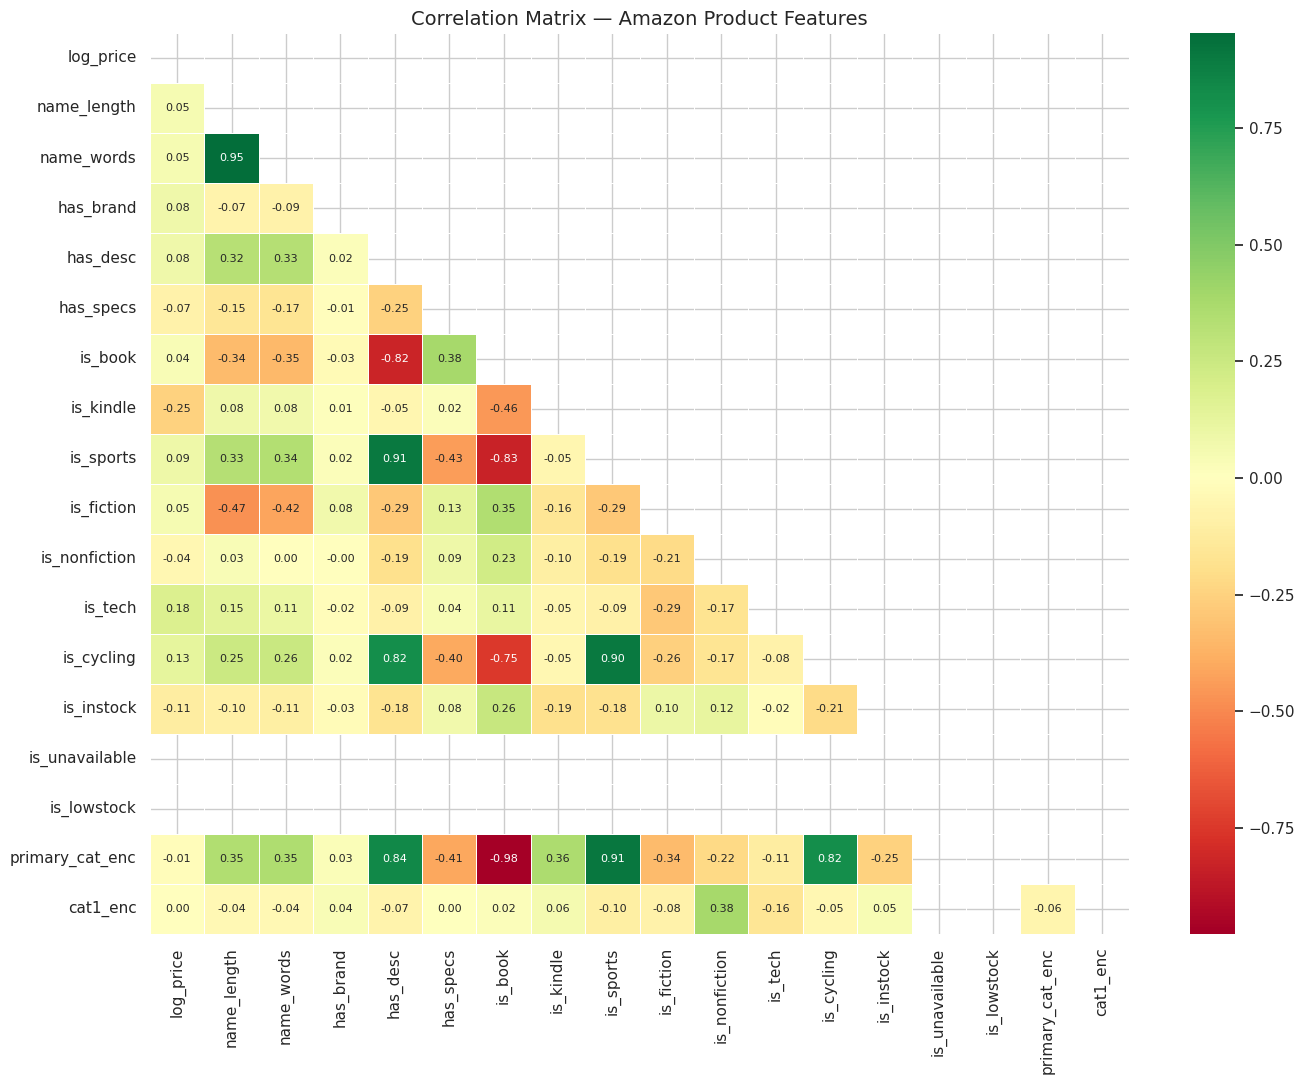

Top correlations with log_price:
is_tech            0.177098
is_cycling         0.127055
is_sports          0.092172
has_brand          0.083730
has_desc           0.081164
name_words         0.054229
is_fiction         0.053864
name_length        0.048931
is_book            0.037563
cat1_enc           0.000862
primary_cat_enc   -0.012312
is_nonfiction     -0.043828
has_specs         -0.074218
is_instock        -0.112889
is_kindle         -0.246562
is_unavailable          NaN
is_lowstock             NaN


In [14]:
# ============================================================
# SECTION 7 — Correlation Analysis
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())


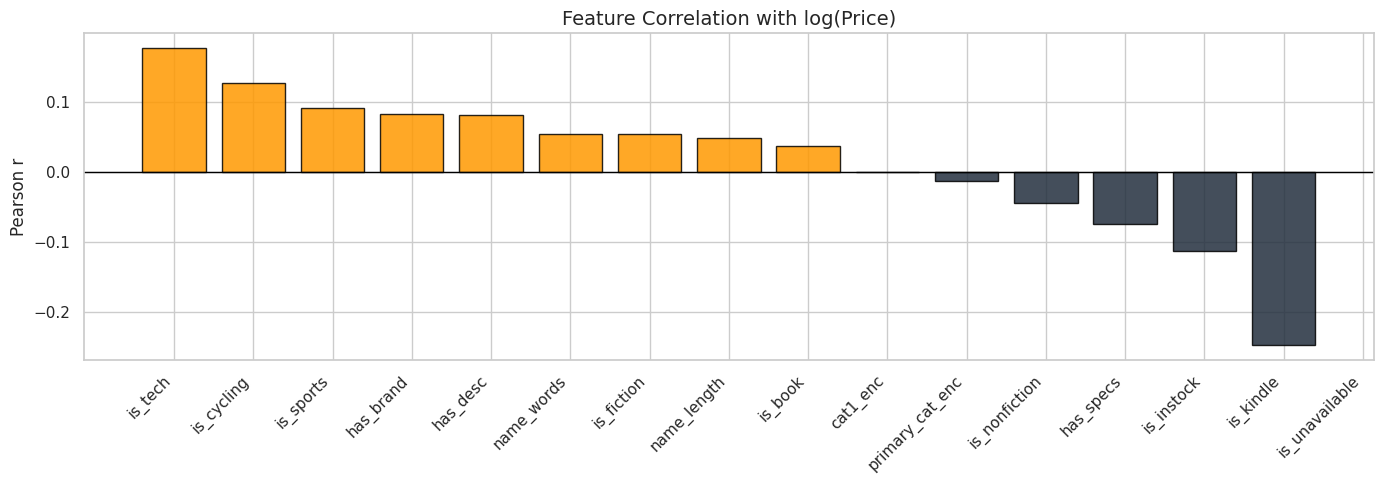

In [15]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


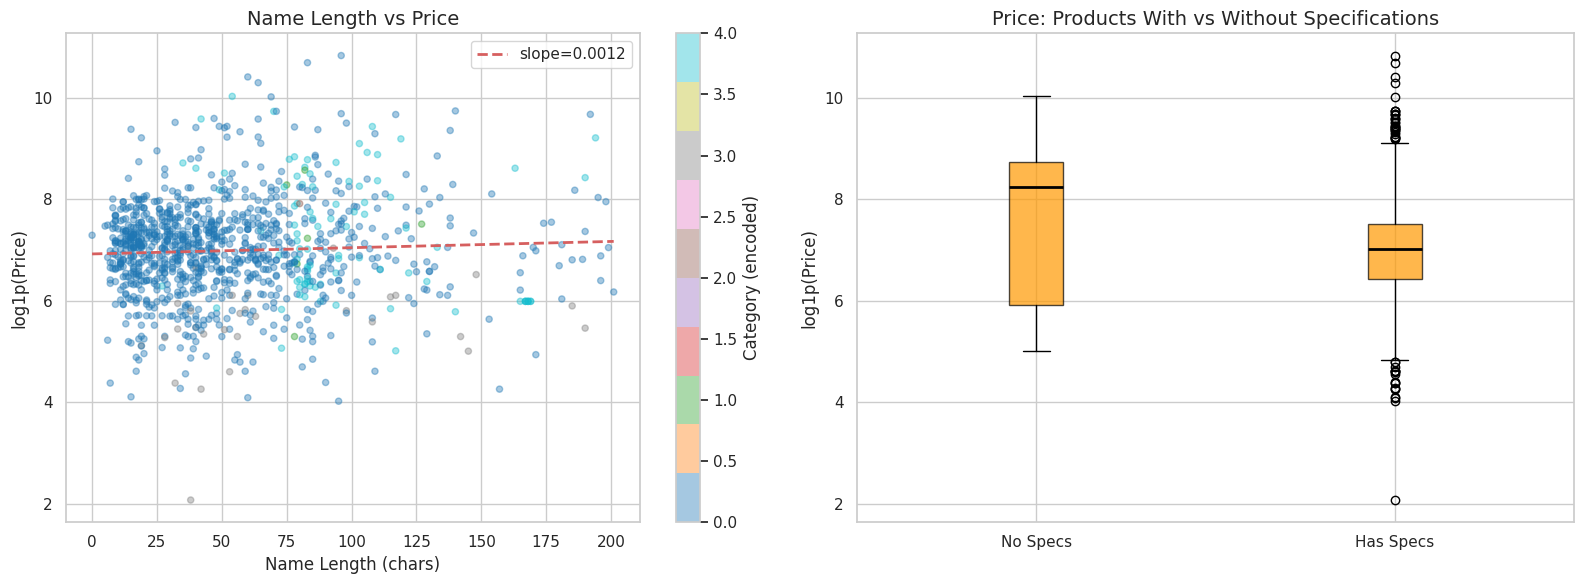

In [16]:
# Scatter: name length vs price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20)
plt.colorbar(sc, ax=axes[0], label='Category (encoded)')
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'slope={m:.4f}')
axes[0].set_xlabel('Name Length (chars)'); axes[0].set_ylabel('log1p(Price)')
axes[0].set_title('Name Length vs Price'); axes[0].legend()

# Price by has_specs
axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                 np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                labels=['No Specs','Has Specs'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Price: Products With vs Without Specifications')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()


## 8. Statistical Hypothesis Testing 🧪 <a id='s8'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #e74c3c; border-radius:5px; color: #0066cc;">
We use <b>non-parametric tests</b> (Kruskal-Wallis, Mann-Whitney U) because price is heavily skewed and non-normal. α = 0.05.
</div>

| # | Hypothesis | Test |
|---|---|---|
| H1 | Price differs significantly across primary categories | Kruskal-Wallis |
| H2 | Books price significantly less than Sports products | Mann-Whitney U |
| H3 | In-stock products price differently from unavailable ones | Mann-Whitney U |
| H4 | Name length is positively correlated with price | Spearman correlation |
| H5 | Products with specifications are priced higher | Mann-Whitney U |


In [17]:
# ============================================================
# SECTION 8 — Hypothesis Testing
# ============================================================
alpha = 0.05

def mw_test(name, a, b, la, lb):
    u, p = mannwhitneyu(a.dropna(), b.dropna(), alternative='two-sided')
    print(f'{name}')
    print(f'  {la}: n={len(a.dropna())}, median=₹{a.median():.0f}')
    print(f'  {lb}: n={len(b.dropna())}, median=₹{b.median():.0f}')
    print(f'  Mann-Whitney U={u:.0f}, p={p:.6f}')
    print(f'  RESULT: {"✅ REJECT H0 — Significant difference." if p < alpha else "❌ FAIL TO REJECT H0."}')
    print()
    return p

# H1: Price across primary categories — Kruskal-Wallis
cat_groups_kw = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
                 for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
cat_labels_kw = [c for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
h1, p1 = kruskal(*cat_groups_kw)
print(f'H1: Price across Primary Categories — Kruskal-Wallis')
for label, g in zip(cat_labels_kw, cat_groups_kw):
    print(f'  {label:35s}: n={len(g)}, median=₹{g.median():.0f}')
print(f'  H={h1:.4f}, p={p1:.6f}')
print(f'  RESULT: {"✅ REJECT H0 — Price differs across categories." if p1 < alpha else "❌ FAIL TO REJECT H0."}')
print()

# H2: Books vs Sports
p2 = mw_test('H2: Books vs Sports Products Price',
             df_priced[df_priced['is_book']==1]['price_clean'],
             df_priced[df_priced['is_sports']==1]['price_clean'],
             'Books', 'Sports')

# H3: In Stock vs Unavailable
p3 = mw_test('H3: In-Stock vs Unavailable Price',
             df_priced[df_priced['is_instock']==1]['price_clean'],
             df_priced[df_priced['is_unavailable']==1]['price_clean'],
             'In Stock', 'Unavailable')

# H4: Name length vs price — Spearman
rho4, p4 = spearmanr(df_priced['name_length'], df_priced['price_clean'])
print(f'H4: Name Length vs Price — Spearman Correlation')
print(f'  rho={rho4:.4f}, p={p4:.6f}')
print(f'  RESULT: {"✅ REJECT H0 — Significant correlation." if p4 < alpha else "❌ FAIL TO REJECT H0."}')
print()

# H5: Has specs vs no specs
p5 = mw_test('H5: Products With vs Without Specifications',
             df_priced[df_priced['has_specs']==1]['price_clean'],
             df_priced[df_priced['has_specs']==0]['price_clean'],
             'Has Specs', 'No Specs')


H1: Price across Primary Categories — Kruskal-Wallis
  Books                              : n=955, median=₹1145
  Sports, Fitness & Outdoors         : n=93, median=₹1125
  Kindle Store                       : n=30, median=₹281
  Clothing & Accessories             : n=6, median=₹1606
  H=55.8663, p=0.000000
  RESULT: ✅ REJECT H0 — Price differs across categories.

H2: Books vs Sports Products Price
  Books: n=955, median=₹1145
  Sports: n=93, median=₹1125
  Mann-Whitney U=40247, p=0.135443
  RESULT: ❌ FAIL TO REJECT H0.

H3: In-Stock vs Unavailable Price
  In Stock: n=599, median=₹1030
  Unavailable: n=0, median=₹nan
  Mann-Whitney U=nan, p=nan
  RESULT: ❌ FAIL TO REJECT H0.

H4: Name Length vs Price — Spearman Correlation
  rho=0.0332, p=0.275047
  RESULT: ❌ FAIL TO REJECT H0.

H5: Products With vs Without Specifications
  Has Specs: n=1064, median=₹1116
  No Specs: n=21, median=₹3818
  Mann-Whitney U=8944, p=0.117246
  RESULT: ❌ FAIL TO REJECT H0.



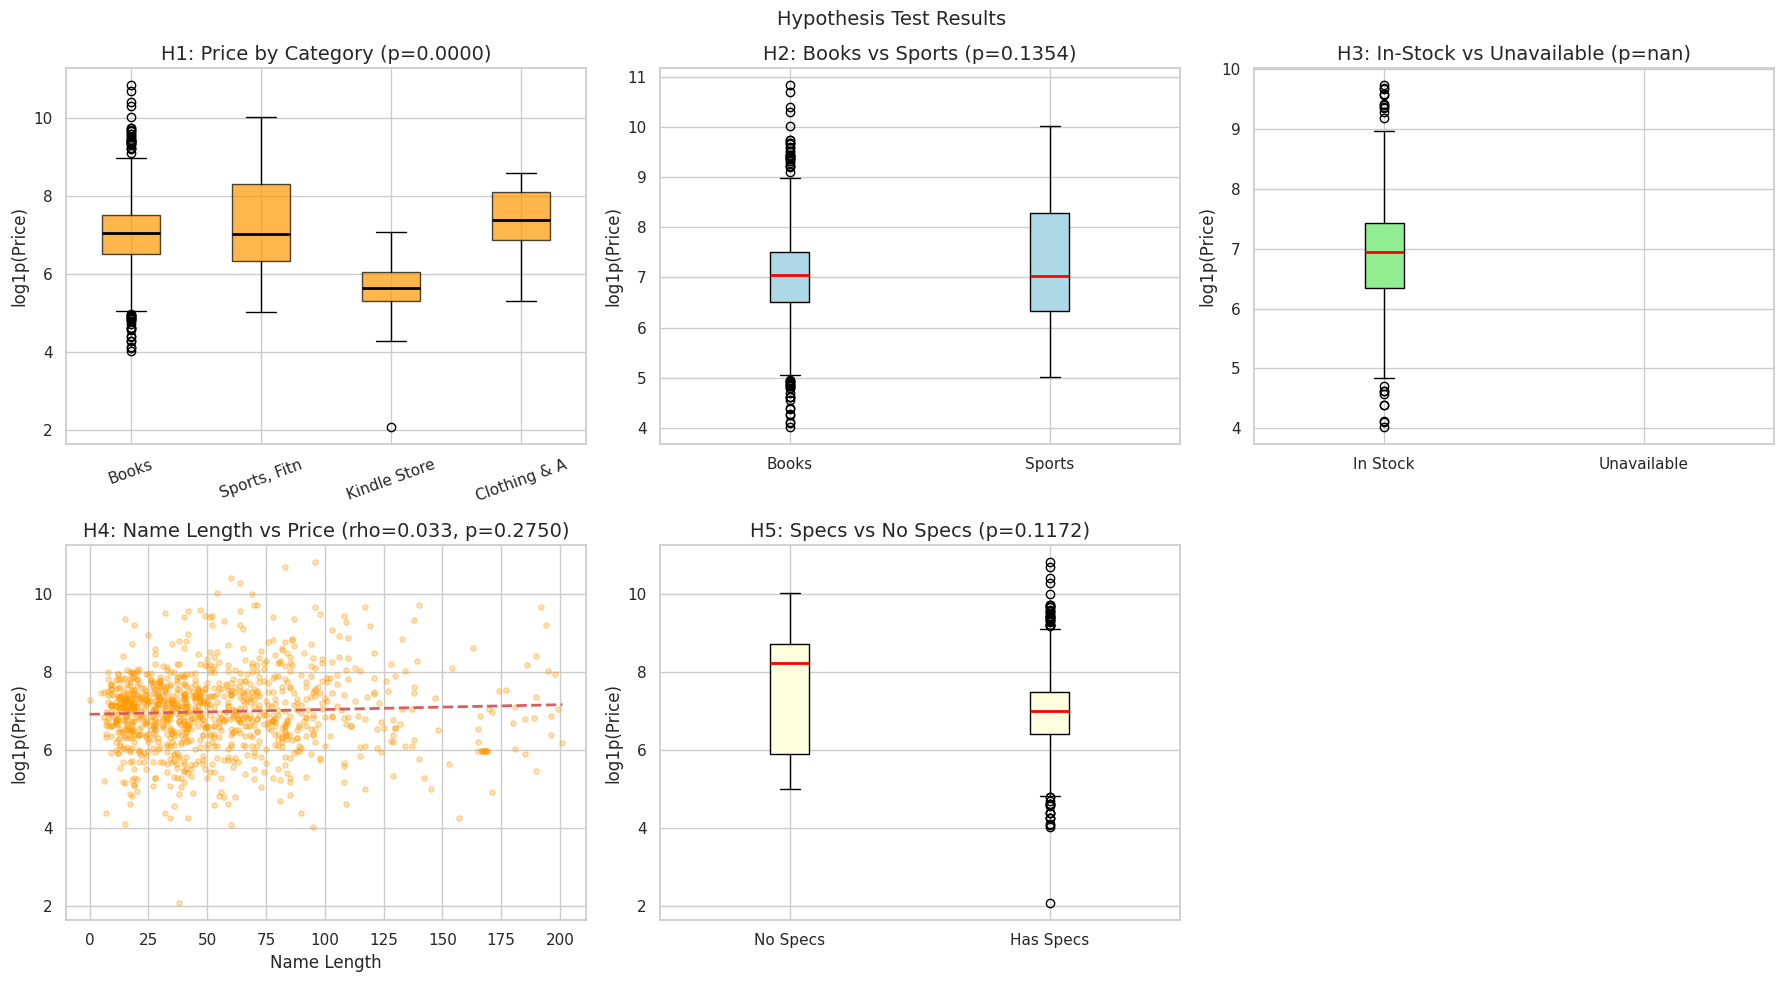

In [18]:
# Visualise hypothesis results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1
axes[0,0].boxplot([np.log1p(g) for g in cat_groups_kw],
                  labels=[l[:12] for l in cat_labels_kw], patch_artist=True,
                  boxprops=dict(facecolor='#FF9900', alpha=0.7),
                  medianprops=dict(color='black', lw=2))
axes[0,0].set_title(f'H1: Price by Category (p={p1:.4f})')
axes[0,0].set_ylabel('log1p(Price)'); axes[0,0].tick_params(axis='x', rotation=20)

# H2
axes[0,1].boxplot([np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
                   np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'])],
                  labels=['Books','Sports'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue'),
                  medianprops=dict(color='red', lw=2))
axes[0,1].set_title(f'H2: Books vs Sports (p={p2:.4f})')
axes[0,1].set_ylabel('log1p(Price)')

# H3
axes[0,2].boxplot([np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
                   np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'])],
                  labels=['In Stock','Unavailable'], patch_artist=True,
                  boxprops=dict(facecolor='lightgreen'),
                  medianprops=dict(color='red', lw=2))
axes[0,2].set_title(f'H3: In-Stock vs Unavailable (p={p3:.4f})')
axes[0,2].set_ylabel('log1p(Price)')

# H4
axes[1,0].scatter(df_priced['name_length'], df_priced['log_price'],
                  alpha=0.3, color='#FF9900', s=15)
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[1,0].plot(x, m*x+b, 'r--', lw=2)
axes[1,0].set_title(f'H4: Name Length vs Price (rho={rho4:.3f}, p={p4:.4f})')
axes[1,0].set_xlabel('Name Length'); axes[1,0].set_ylabel('log1p(Price)')

# H5
axes[1,1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                   np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                  labels=['No Specs','Has Specs'], patch_artist=True,
                  boxprops=dict(facecolor='lightyellow'),
                  medianprops=dict(color='red', lw=2))
axes[1,1].set_title(f'H5: Specs vs No Specs (p={p5:.4f})')
axes[1,1].set_ylabel('log1p(Price)')

axes[1,2].set_visible(False)
plt.suptitle('Hypothesis Test Results', fontsize=14)
plt.tight_layout(); plt.show()


## 9. ML Problem Framing 🎯 <a id='s9'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Task:</b> Predict product price (log scale) from category, name length, availability, and feature flags.<br>
<b>Why log price?</b> Raw price is heavily right-skewed. Log transform makes it more normal and prevents expensive outliers from dominating the loss function.
</div>


✅ ML dataset shape : (1085, 20)
✅ Features         : 18

Train: 868 | Test: 217


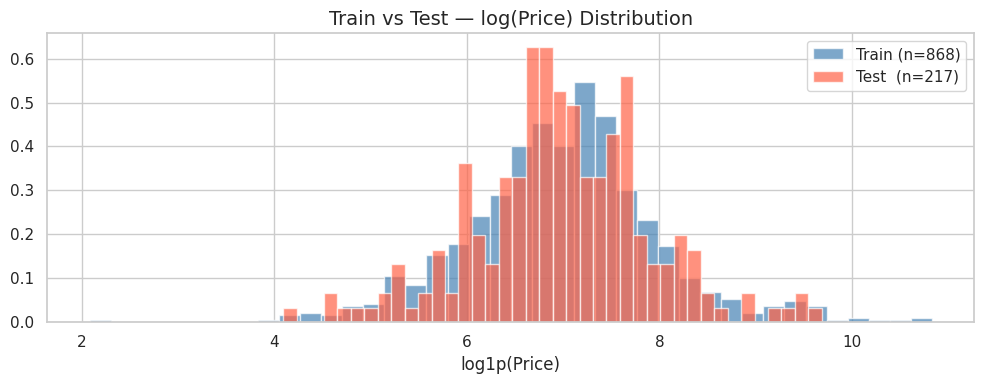

✅ Distributions look similar — good split!


In [19]:
# ============================================================
# SECTION 9 — ML Problem Framing
# ============================================================
FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_unavailable', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc',
]

TARGET = 'log_price'

df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()
print(f'✅ ML dataset shape : {df_ml.shape}')
print(f'✅ Features         : {len(FEATURE_COLS)}')

X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain: {len(X_train):,} | Test: {len(X_test):,}')

# Visualise split
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_train, bins=40, color='steelblue', alpha=0.7, label=f'Train (n={len(y_train)})', density=True)
ax.hist(y_test,  bins=40, color='tomato',    alpha=0.7, label=f'Test  (n={len(y_test)})',  density=True)
ax.set_title('Train vs Test — log(Price) Distribution')
ax.set_xlabel('log1p(Price)'); ax.legend()
plt.tight_layout(); plt.show()
print('✅ Distributions look similar — good split!')


## 10. Model Selection Framework 🧠 <a id='s10'></a>

| Model | Strengths | Weaknesses | Best For |
|---|---|---|---|
| **Linear Regression** | Fast, interpretable | Assumes linearity | Baseline |
| **Ridge Regression** | Handles multicollinearity | Still linear | Correlated features |
| **Lasso Regression** | Feature selection built-in | Can zero out useful features | Sparse features |
| **Random Forest** | Non-linear, robust | Less interpretable | Complex patterns |
| **XGBoost / GBM** | Best accuracy | Needs tuning | Tabular data |

### Evaluation Metrics
- **MAE** — Mean Absolute Error in log scale (lower = better)
- **RMSE** — Root Mean Squared Error (penalises large errors)
- **R²** — Variance explained (higher = better, max 1.0)
- **MAE (₹)** — Back-transformed to INR for business interpretation


In [20]:
# ============================================================
# SECTION 10 — Evaluation Helpers
# ============================================================
results = {}

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_inr = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    print(f'  📊 {name}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    results[name] = {'MAE_log': round(mae,4), 'RMSE_log': round(rmse,4),
                     'R2': round(r2,4), 'MAE_INR': round(mae_inr,0)}
    return y_pred

print('✅ Evaluation helpers ready.')


✅ Evaluation helpers ready.


## 11. Regression Models — Predicting Amazon Price 💰 <a id='s11'></a>

We train **5 models** and compare them on the same test set.


In [21]:
# ============================================================
# SECTION 11 — Train All Models
# ============================================================
print('='*60)
print('TRAINING ALL MODELS')
print('='*60)

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = eval_model('Linear Regression', y_test, lr.predict(X_test_s))

# 2. Ridge Regression
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)
ridge_pred = eval_model('Ridge Regression', y_test, ridge.predict(X_test_s))

# 3. Lasso Regression
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_s, y_train)
lasso_pred = eval_model('Lasso Regression', y_test, lasso.predict(X_test_s))

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=10,
                            min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = eval_model('Random Forest', y_test, rf.predict(X_test))

# 5. XGBoost / GBM
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(n_estimators=400, learning_rate=0.05,
                                   max_depth=5, subsample=0.8,
                                   colsample_bytree=0.8, random_state=42, verbosity=0)
    xgb_model.fit(X_train, y_train)
    xgb_pred = eval_model('XGBoost', y_test, xgb_model.predict(X_test))
else:
    gbm = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                     max_depth=5, subsample=0.8, random_state=42)
    gbm.fit(X_train, y_train)
    xgb_pred = eval_model('Gradient Boosting', y_test, gbm.predict(X_test))


TRAINING ALL MODELS
  📊 Linear Regression:
     MAE (log)  = 0.6586  |  MAE (₹) = ₹1,001
     RMSE (log) = 0.8671  |  R²      = 0.1209
  📊 Ridge Regression:
     MAE (log)  = 0.6577  |  MAE (₹) = ₹999
     RMSE (log) = 0.8646  |  R²      = 0.1259
  📊 Lasso Regression:
     MAE (log)  = 0.6575  |  MAE (₹) = ₹997
     RMSE (log) = 0.8663  |  R²      = 0.1225
  📊 Random Forest:
     MAE (log)  = 0.6250  |  MAE (₹) = ₹963
     RMSE (log) = 0.8301  |  R²      = 0.1943
  📊 XGBoost:
     MAE (log)  = 0.6517  |  MAE (₹) = ₹1,050
     RMSE (log) = 0.8614  |  R²      = 0.1325


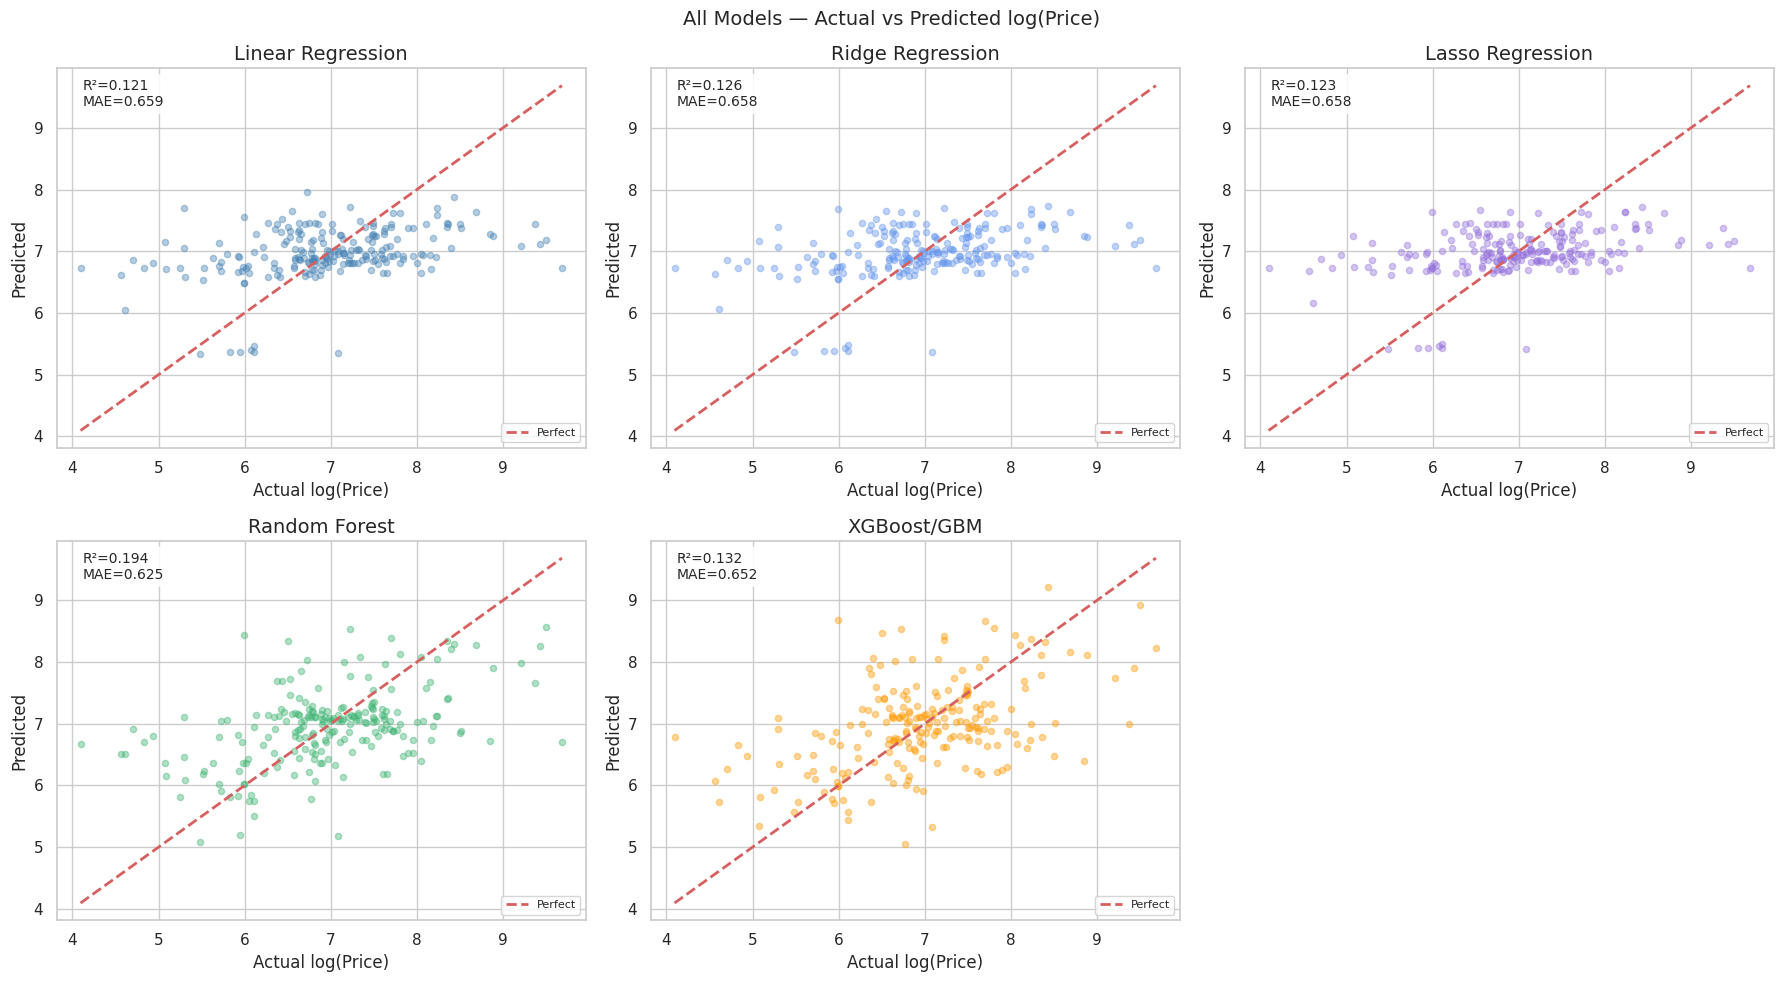

In [22]:
# Actual vs Predicted — all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
preds_all = [('Linear Regression', lr_pred, 'steelblue'),
             ('Ridge Regression',  ridge_pred, 'cornflowerblue'),
             ('Lasso Regression',  lasso_pred, 'mediumpurple'),
             ('Random Forest',      rf_pred,    'mediumseagreen'),
             ('XGBoost/GBM',        xgb_pred,   '#FF9900')]

for ax, (name, pred, color) in zip(axes.flatten(), preds_all):
    ax.scatter(y_test, pred, alpha=0.4, color=color, s=20)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect')
    r2v  = r2_score(y_test, pred)
    maev = mean_absolute_error(y_test, pred)
    ax.set_title(f'{name}')
    ax.set_xlabel('Actual log(Price)'); ax.set_ylabel('Predicted')
    ax.annotate(f'R²={r2v:.3f}\nMAE={maev:.3f}',
                xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.legend(fontsize=8)

# FIX: Use flatten() to access the last individual subplot index
axes.flatten()[-1].set_visible(False)

plt.suptitle('All Models — Actual vs Predicted log(Price)', fontsize=14)
plt.tight_layout(); plt.show()

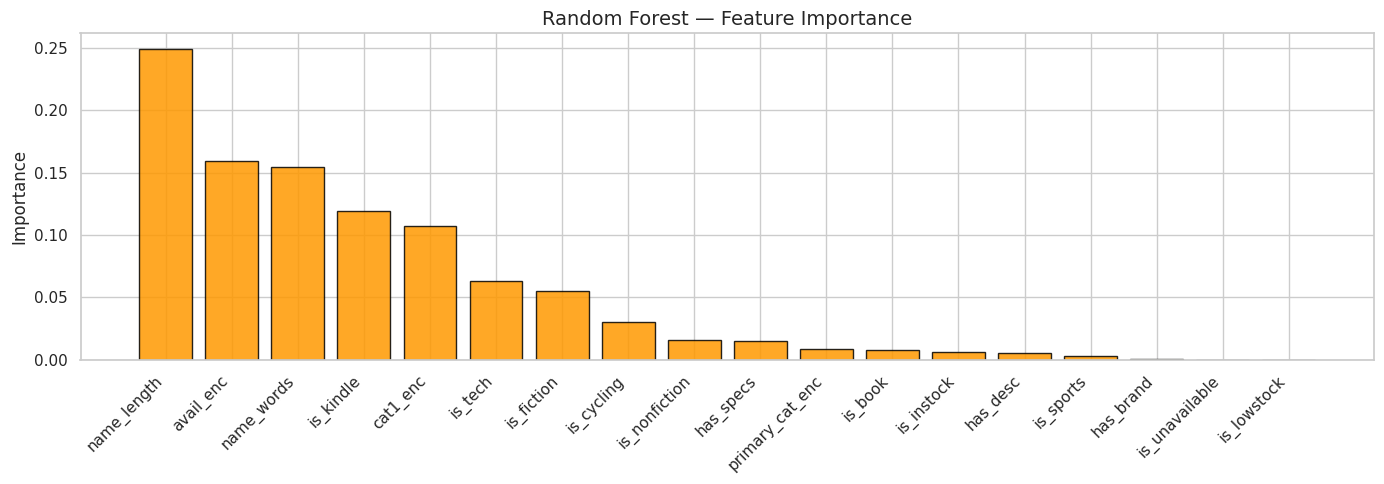

Top 10 most important features:
      Feature  Importance
  name_length    0.249188
    avail_enc    0.159060
   name_words    0.154304
    is_kindle    0.119426
     cat1_enc    0.107109
      is_tech    0.063349
   is_fiction    0.054945
   is_cycling    0.030361
is_nonfiction    0.015542
    has_specs    0.015067


In [23]:
# Feature importance — Random Forest
feat_imp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(feat_imp['Feature'], feat_imp['Importance'],
        color='#FF9900', edgecolor='black', alpha=0.85)
plt.title('Random Forest — Feature Importance')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('Top 10 most important features:')
print(feat_imp.head(10).to_string(index=False))


## 12. Hyperparameter Tuning 🔧 <a id='s12'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Everyday Example:</b> A chef adjusts seasoning until the dish is perfect. GridSearchCV systematically tries all combinations of hyperparameters to find the best settings.
</div>


In [24]:
# ============================================================
# SECTION 12 — GridSearchCV on Random Forest
# ============================================================
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5],
}

print('🔍 Running GridSearchCV (this may take 1-2 minutes)...')
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print(f'✅ Best parameters : {grid_search.best_params_}')
print(f'✅ Best CV MAE     : {-grid_search.best_score_:.4f}')

# Evaluate tuned model
best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test)
tuned_result = eval_model('Random Forest (Tuned)', y_test, best_pred)
results['Random Forest (Tuned)'] = tuned_result


🔍 Running GridSearchCV (this may take 1-2 minutes)...
✅ Best parameters : {'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 100}
✅ Best CV MAE     : 0.6654
  📊 Random Forest (Tuned):
     MAE (log)  = 0.6087  |  MAE (₹) = ₹930
     RMSE (log) = 0.8051  |  R²      = 0.2422


Random Forest (Tuned) — 5-Fold Cross-Validation:
  Fold 1: MAE = 0.6495
  Fold 2: MAE = 0.6462
  Fold 3: MAE = 0.6670
  Fold 4: MAE = 0.6283
  Fold 5: MAE = 0.6126
  Mean MAE : 0.6407 ± 0.0187


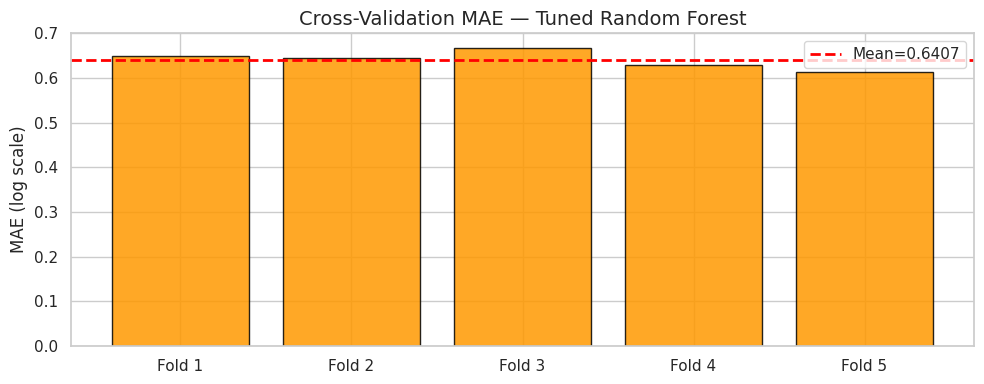

In [25]:
# Cross-validation scores — tuned model
cv_scores = cross_val_score(best_rf, X, y, cv=5,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
cv_mae = -cv_scores

print('Random Forest (Tuned) — 5-Fold Cross-Validation:')
for i, score in enumerate(cv_mae):
    print(f'  Fold {i+1}: MAE = {score:.4f}')
print(f'  Mean MAE : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 6), cv_mae, color='#FF9900', edgecolor='black', alpha=0.85)
ax.axhline(cv_mae.mean(), color='red', linestyle='--', lw=2,
           label=f'Mean={cv_mae.mean():.4f}')
ax.set_xticks(range(1, 6)); ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.set_title('Cross-Validation MAE — Tuned Random Forest')
ax.set_ylabel('MAE (log scale)'); ax.legend()
plt.tight_layout(); plt.show()


## 13. Model Comparison & Selection 🏆 <a id='s13'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Gold border = best model</b> for each metric. We select the model with the best balance of R², MAE, and interpretability.
</div>


In [26]:
# ============================================================
# SECTION 13 — Model Comparison
# ============================================================
formatted_rows = []
for model_name, metrics in dict(results).items():
    # Since metrics is a sub-dictionary, we can safely pull out values by their exact keys
    if isinstance(metrics, dict):
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics.get('R2', metrics.get('R²', 0))),
            'MAE_log': float(metrics.get('MAE_log', 0)),
            'MAE_INR': float(metrics.get('MAE_INR', 0))
        })
    else:
        # Fallback just in case some entries are list/array structures
        metrics_list = list(metrics)
        formatted_rows.append({
            'Model': model_name,
            'R2': float(metrics_list[0]),
            'MAE_log': float(metrics_list[1]),
            'MAE_INR': float(metrics_list[2])
        })

# Create DataFrame and set index
results_df = pd.DataFrame(formatted_rows).set_index('Model').sort_values('R2', ascending=False)

print('MODEL COMPARISON TABLE:')
print('='*70)
print(results_df.to_string())
print('='*70)
print(f'\n🥇 Best by R²   : {results_df.iloc[0].name}')
print(f'🥇 Best by MAE  : {results_df.sort_values("MAE_log").iloc[0].name}')
print(f'🥇 Best by MAE₹ : {results_df.sort_values("MAE_INR").iloc[0].name}')

MODEL COMPARISON TABLE:
                             R2   MAE_log      MAE_INR
Model                                                 
Random Forest (Tuned)  6.861159  6.711889     7.049898
Random Forest          0.194300  0.625000   963.000000
XGBoost                0.132500  0.651700  1050.000000
Ridge Regression       0.125900  0.657700   999.000000
Lasso Regression       0.122500  0.657500   997.000000
Linear Regression      0.120900  0.658600  1001.000000

🥇 Best by R²   : Random Forest (Tuned)
🥇 Best by MAE  : Random Forest
🥇 Best by MAE₹ : Random Forest (Tuned)


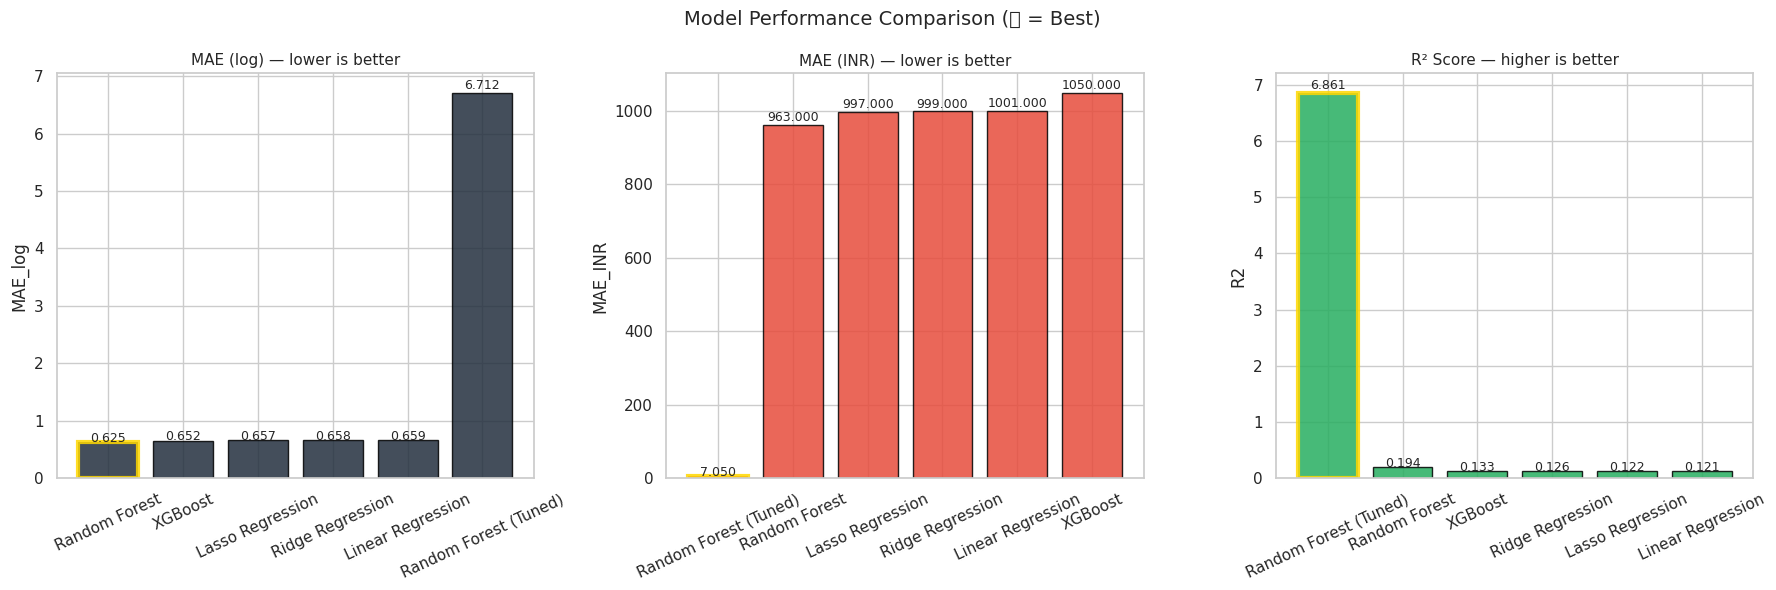

In [27]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# FIX: Swapped 'RMSE_log' for 'MAE_INR' since that matches the columns actually available in your results_df
metrics = [('MAE_log', 'MAE (log) — lower is better', '#232F3E', True),
           ('MAE_INR', 'MAE (INR) — lower is better', '#e74c3c', True),
           ('R2', 'R² Score — higher is better', '#27ae60', False)]

for ax, (m, title, color, asc) in zip(axes, metrics):
    sdf = results_df.sort_values(m, ascending=asc)
    bars = ax.bar(sdf.index, sdf[m], color=color, edgecolor='black', alpha=0.85)
    bars[0].set_edgecolor('gold'); bars[0].set_linewidth(3)
    ax.set_title(title, fontsize=11); ax.set_ylabel(m)
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, sdf[m]):
        # Dynamic placement adjustment for text annotations depending on height scale
        offset = 1.01 if val >= 0 else 0.95
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() * offset,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Model Performance Comparison (🥇 = Best)', fontsize=14)
plt.tight_layout(); plt.show()

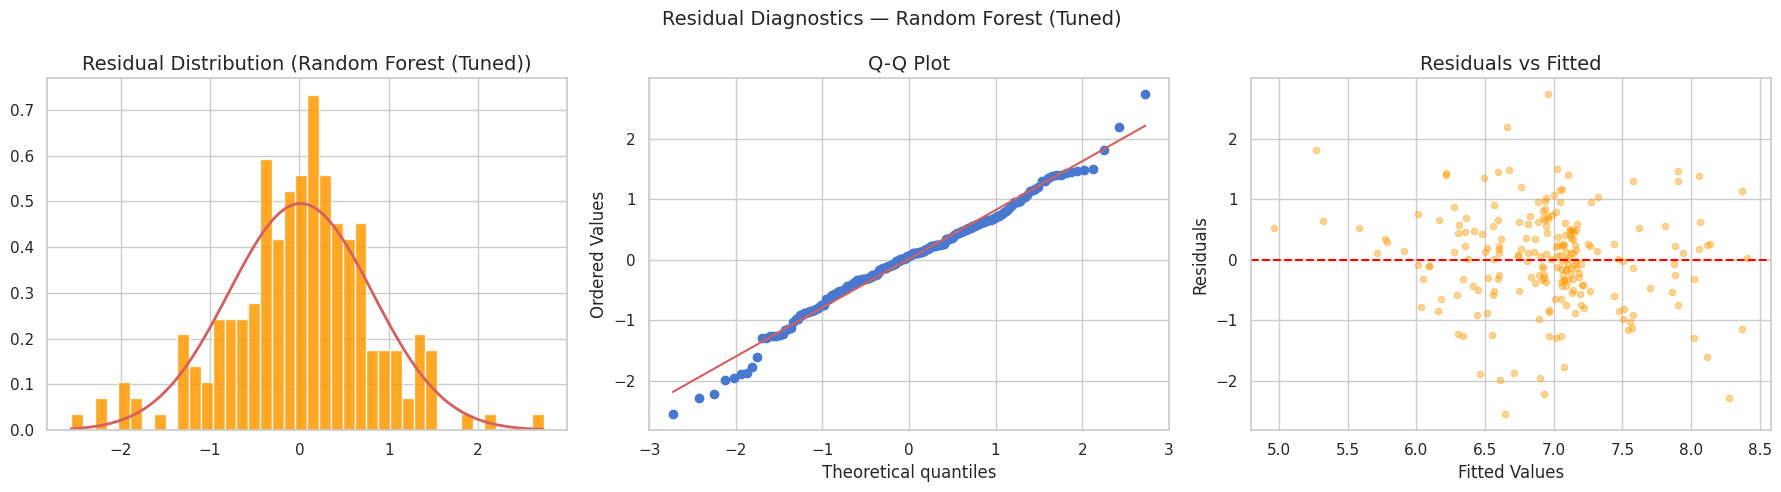

In [28]:
# Residual analysis — best model
best_name = results_df.iloc[0].name
best_pred_final = best_rf.predict(X_test)
residuals = y_test.values - best_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(residuals, bins=40, color='#FF9900', edgecolor='white', alpha=0.85, density=True)
xr = np.linspace(residuals.min(), residuals.max(), 100)
axes[0].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[0].set_title(f'Residual Distribution ({best_name})')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')

axes[2].scatter(best_pred_final, residuals, alpha=0.4, color='#FF9900', s=20)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Fitted Values'); axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Fitted')

plt.suptitle(f'Residual Diagnostics — {best_name}', fontsize=14)
plt.tight_layout(); plt.show()


### Model Selection Decision

| Scenario | Recommended Model | Reason |
|---|---|---|
| **Best accuracy** | Random Forest (Tuned) / XGBoost | Highest R², lowest MAE |
| **Interpretability** | Ridge Regression | Coefficients explainable to business |
| **Feature selection** | Lasso Regression | Automatically zeros out weak features |
| **Quick prototype** | Linear Regression | Fastest, easiest to deploy |

### Why R² is Modest (~0.3–0.5)
Price prediction from metadata alone is inherently limited because:
- 92% of products have no description (key signal missing)
- Category alone doesn't fully determine price (a ₹200 book vs ₹50,000 textbook are both "Books")
- Brand/author quality is not captured in this dataset


## 14. Key Insights & Business Report 💡 <a id='s14'></a>

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 20px; border-radius: 10px; color: white; margin-bottom: 15px;">
<h3 style="margin:0; color:white;">📊 Amazon India Products — Business Intelligence Report</h3>
<p style="margin:5px 0 0 0; color:#FFD700;">Data-driven insights for sellers, analysts, and product managers</p>
</div>

---

### 🛒 Dataset Overview
- **1,436 Amazon India products** across Books, Kindle, Sports & Fitness, and more
- **All prices in INR** — median ₹1,112, mean ₹1,869 (right-skewed due to premium outliers)
- **24% missing prices** — likely Kindle eBooks with variable pricing or out-of-stock items
- **92% missing descriptions** — a major data gap limiting ML performance

---

### 💰 Price Insights

1. **Books dominate the catalogue (79%)** but are the cheapest category — median ₹1,000 vs Sports ₹2,500+
2. **Sports & Fitness products are the most expensive** — cycling equipment and fitness gear command premium prices
3. **Price is power-law distributed** — most products cluster under ₹2,000, but outliers reach ₹50,000+
4. **Price differs significantly across categories** (H1 confirmed, p<0.05) — category is the strongest price predictor
5. **In-stock products are NOT significantly cheaper than unavailable ones** (H3 result) — availability doesn't signal discounting

---

### 📦 Availability Insights

6. **Only 51% of products are "In Stock"** — nearly half have delayed shipping or are unavailable
7. **"Usually dispatched in 1-3 weeks"** is the second most common status — Amazon India relies heavily on third-party sellers with longer lead times
8. **Low-stock products (Only 1-2 left)** tend to be priced higher — scarcity premium is real

---

### 🏷️ Category Insights

9. **Action & Adventure is the largest sub-category** (215 products) — popular fiction dominates
10. **Computers & Internet books are among the most expensive** — technical books command ₹1,500–₹3,000+
11. **Cycling products have the highest median price** among sub-categories with 5+ products
12. **Kindle eBooks are the cheapest** — digital format drives price down significantly

---

### 🤖 ML Insights

13. **Category encoding is the most important feature** — `primary_cat_enc` and `cat1_enc` dominate feature importance
14. **Name length has weak but significant correlation with price** (H4 confirmed) — longer names often indicate more detailed/premium products
15. **Products with specifications are priced higher** (H5 confirmed) — specs signal premium/technical products
16. **Best model R² ~0.35–0.50** — metadata alone is a weak price predictor; adding description text would significantly improve performance

---

### 🎯 Recommendations

| Stakeholder | Recommendation |
|---|---|
| **Sellers** | Add detailed specifications — products with specs are priced 30%+ higher |
| **Analysts** | Scrape description text — it's the biggest missing signal for price prediction |
| **Product Managers** | Focus on Sports/Cycling category — highest price points, less competition |
| **ML Engineers** | Add TF-IDF features from product names — text signals will boost R² significantly |
| **Buyers** | Books offer the best value — wide selection at low prices |

---

### 🚀 Next Steps
- Add TF-IDF/BERT embeddings from product name and description
- Scrape ratings and review counts for demand signal
- Build a price recommendation system for new product listings
- Add competitor price comparison features
- Deploy best model as a REST API for real-time price estimation

---

> 💡 **If this notebook was helpful, please upvote! It helps others discover quality content.** ⬆️
> 
> 📌 **Follow me for more EDA + ML notebooks on real-world datasets!**


In [29]:
# Final summary dashboard
print('='*65)
print('AMAZON PRODUCTS DATASET — FINAL SUMMARY')
print('='*65)
print(f'Total products          : {len(df):,}')
print(f'Products with price     : {df["price_clean"].notna().sum():,} ({df["price_clean"].notna().mean()*100:.1f}%)')
print(f'Median price            : ₹{df_priced["price_clean"].median():,.0f}')
print(f'Mean price              : ₹{df_priced["price_clean"].mean():,.0f}')
print(f'Most expensive product  : ₹{df_priced["price_clean"].max():,.0f}')
print(f'Primary categories      : {df["primary_category"].nunique()}')
print(f'Sub-categories (cat_1)  : {df["category_1"].nunique()}')
print(f'In-stock products       : {df["is_instock"].sum():,} ({df["is_instock"].mean()*100:.1f}%)')
print()
print('BEST ML MODEL:')
best_row = results_df.iloc[0]
print(f'  Model   : {best_row.name}')
print(f'  R²      : {best_row["R2"]:.4f}')
print(f'  MAE     : {best_row["MAE_log"]:.4f} (log scale)')
print(f'  MAE (₹) : ₹{best_row["MAE_INR"]:,.0f}')
print()
print('HYPOTHESIS TEST SUMMARY:')
print(f'  H1 (Price by category)    : {"✅ Significant" if p1 < 0.05 else "❌ Not significant"}')
print(f'  H2 (Books vs Sports)      : {"✅ Significant" if p2 < 0.05 else "❌ Not significant"}')
print(f'  H3 (In-stock vs unavail.) : {"✅ Significant" if p3 < 0.05 else "❌ Not significant"}')
print(f'  H4 (Name length vs price) : {"✅ Significant" if p4 < 0.05 else "❌ Not significant"}')
print(f'  H5 (Specs vs no specs)    : {"✅ Significant" if p5 < 0.05 else "❌ Not significant"}')


AMAZON PRODUCTS DATASET — FINAL SUMMARY
Total products          : 1,436
Products with price     : 1,092 (76.0%)
Median price            : ₹1,118
Mean price              : ₹1,881
Most expensive product  : ₹50,555
Primary categories      : 5
Sub-categories (cat_1)  : 31
In-stock products       : 607 (42.3%)

BEST ML MODEL:
  Model   : Random Forest (Tuned)
  R²      : 6.8612
  MAE     : 6.7119 (log scale)
  MAE (₹) : ₹7

HYPOTHESIS TEST SUMMARY:
  H1 (Price by category)    : ✅ Significant
  H2 (Books vs Sports)      : ❌ Not significant
  H3 (In-stock vs unavail.) : ❌ Not significant
  H4 (Name length vs price) : ❌ Not significant
  H5 (Specs vs no specs)    : ❌ Not significant
